#  MacroSense: Exploratory Data Analysis (EDA)

**Author:**  Aremu Gideon Marvelous 

**Date:** May 2026  

**Notebook:** 02: Exploratory Data Analysis  

---

## What Is This Notebook About?

This notebook is our detective phase. Before we build any machine 
learning model we must first deeply understand the data we are 
working with.

Exploratory Data Analysis (EDA) is the process of examining our 
data carefully — studying its structure, identifying problems, 
discovering patterns, and developing genuine insight about what 
the data is telling us.

Think of it like a doctor examining a patient before prescribing 
medicine. A good doctor never guesses. They examine first. 
We do the same with our data.

---

## What This Notebook Will Do

| Task | Purpose |
|---|---|
| Load and inspect the raw data | Understand what we are working with |
| Trim the dataset to usable range | Remove rows where most data is missing |
| Handle GDP quarterly values | Ensure no gaps in our monthly table |
| Plot every variable over time | See how each indicator behaves historically |
| Shade recession periods on charts | See how each variable behaves during downturns |
| Build a correlation heatmap | Understand relationships between variables |
| Write economic interpretations | Extract genuine insight from what we see |

---

##  Why EDA Is Non-Negotiable

Skipping EDA is one of the most dangerous mistakes in data science. 
Without it you risk:

- Feeding missing values into a model without knowing it
- Missing critical patterns that inform your feature engineering
- Building a model on data that does not mean what you think it means
- Producing results you cannot explain or defend

Every decision we make in Notebooks 3 through 6 will be 
informed by what we discover here. EDA is the foundation 
of everything that follows.

---

##  Input
- `data/raw_fred_data.csv`, saved in Notebook 1

##  Output
- `charts/`, all visualisations saved here
- Key findings documented in markdown cells throughout

**Previous Notebook:** 01 — Data Collection  
**Next Notebook:** 03 — Feature Engineering

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import os
print(os.getcwd())

C:\Users\HP\Documents\MacroSense\notebooks


## Load and Clean the Data
We load the raw data saved in Notebook 1, trim it to 1992 where 
all variables become simultaneously available, forward fill GDP's 
quarterly gaps, and drop genuinely unknown rows at the end.

**Key decisions made here:**
- **Trim to 1992** — RetailSales is the latest starting series
- **Forward fill** — fills monthly gaps between quarterly GDP releases
- **Drop tail** — removes months with no real data yet released

In [3]:
# Load Data
df = pd.read_csv("../data/raw_fred_data.csv", index_col=0, parse_dates=True)
df.tail()

,GDP,CPI,Unemployment,FedFunds,M2,YieldCurve,IndPro,RetailSales,Sentiment,JoblessClaims
2026-01-31,24174.527,326.588,4.3,3.64,22429.3,0.74,101.4737,734503.0,56.4,230000.0
2026-02-28,NaN,327.460,4.4,3.64,22627.3,0.59,102.1009,741278.0,56.6,214000.0
2026-03-31,NaN,330.293,4.3,3.64,22686.0,0.51,101.8060,753370.0,53.3,203000.0
2026-04-30,NaN,332.407,4.3,3.64,NaN,0.52,102.4963,757085.0,NaN,190000.0
2026-05-31,NaN,NaN,NaN,NaN,NaN,0.47,NaN,NaN,NaN,211000.0


In [4]:
# Trim Data to the start date
df = df[df.index >= "1992"]
df.tail()

,GDP,CPI,Unemployment,FedFunds,M2,YieldCurve,IndPro,RetailSales,Sentiment,JoblessClaims
2026-01-31,24174.527,326.588,4.3,3.64,22429.3,0.74,101.4737,734503.0,56.4,230000.0
2026-02-28,NaN,327.460,4.4,3.64,22627.3,0.59,102.1009,741278.0,56.6,214000.0
2026-03-31,NaN,330.293,4.3,3.64,22686.0,0.51,101.8060,753370.0,53.3,203000.0
2026-04-30,NaN,332.407,4.3,3.64,NaN,0.52,102.4963,757085.0,NaN,190000.0
2026-05-31,NaN,NaN,NaN,NaN,NaN,0.47,NaN,NaN,NaN,211000.0


In [5]:
# Checking Missing Values after Trimming
df.isnull().sum()

GDP              276
CPI                2
Unemployment       2
FedFunds           1
M2                 2
YieldCurve         0
IndPro             1
RetailSales        1
Sentiment          2
JoblessClaims      0
dtype: int64

In [6]:
# Forward_Filling Missing Values because the GDP in the US is released Quarterly
df = df.ffill()
df.tail()

,GDP,CPI,Unemployment,FedFunds,M2,YieldCurve,IndPro,RetailSales,Sentiment,JoblessClaims
2026-01-31,24174.527,326.588,4.3,3.64,22429.3,0.74,101.4737,734503.0,56.4,230000.0
2026-02-28,24174.527,327.460,4.4,3.64,22627.3,0.59,102.1009,741278.0,56.6,214000.0
2026-03-31,24174.527,330.293,4.3,3.64,22686.0,0.51,101.8060,753370.0,53.3,203000.0
2026-04-30,24174.527,332.407,4.3,3.64,22686.0,0.52,102.4963,757085.0,53.3,190000.0
2026-05-31,24174.527,332.407,4.3,3.64,22686.0,0.47,102.4963,757085.0,53.3,211000.0


In [7]:
df = df.drop("2026-05-31")
df.tail()

,GDP,CPI,Unemployment,FedFunds,M2,YieldCurve,IndPro,RetailSales,Sentiment,JoblessClaims
2025-12-31,24055.749,326.031,4.4,3.72,22353.6,0.71,101.5203,734717.0,52.9,203000.0
2026-01-31,24174.527,326.588,4.3,3.64,22429.3,0.74,101.4737,734503.0,56.4,230000.0
2026-02-28,24174.527,327.460,4.4,3.64,22627.3,0.59,102.1009,741278.0,56.6,214000.0
2026-03-31,24174.527,330.293,4.3,3.64,22686.0,0.51,101.8060,753370.0,53.3,203000.0
2026-04-30,24174.527,332.407,4.3,3.64,22686.0,0.52,102.4963,757085.0,53.3,190000.0


In [8]:
df_trim = df.copy()
save_path = os.path.join('..', 'data', 'cleaned_fred_data.csv')
df_trim.to_csv(save_path)

In [9]:
df_trim.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 412 entries, 1992-01-31 to 2026-04-30
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GDP            412 non-null    float64
 1   CPI            412 non-null    float64
 2   Unemployment   412 non-null    float64
 3   FedFunds       412 non-null    float64
 4   M2             412 non-null    float64
 5   YieldCurve     412 non-null    float64
 6   IndPro         412 non-null    float64
 7   RetailSales    412 non-null    float64
 8   Sentiment      412 non-null    float64
 9   JoblessClaims  412 non-null    float64
dtypes: float64(10)
memory usage: 35.4 KB


In [10]:
df_trim.describe()

,GDP,CPI,Unemployment,FedFunds,M2,YieldCurve,IndPro,RetailSales,Sentiment,JoblessClaims
count,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,4.120000e+02
mean,16818.596867,215.890289,5.628641,2.652816,10025.263592,1.005947,92.094826,385174.320388,84.447573,3.669393e+05
std,3793.424114,50.691625,1.774201,2.161597,6073.879590,0.925602,11.182768,157422.456844,14.352691,3.455680e+05
min,10236.435000,138.300000,3.400000,0.050000,3381.200000,-1.060000,61.461600,158647.000000,50.000000,1.900000e+05
25%,14145.312000,172.700000,4.300000,0.197500,4812.450000,0.240000,88.486275,268191.000000,73.750000,2.687500e+05
50%,16743.162000,215.326500,5.200000,2.385000,8352.850000,0.840000,96.451400,356456.000000,87.500000,3.300000e+05
75%,19545.403250,246.482750,6.400000,4.857500,13758.850000,1.850000,100.508125,466596.000000,95.100000,3.795000e+05
max,24174.527000,332.407000,14.800000,6.540000,22686.000000,2.840000,104.100400,757085.000000,112.000000,5.946000e+06


In [11]:
from dotenv import load_dotenv # loads our secret API key safely
from fredapi import Fred       # connects to FRED database
# Load API key safely from .env file
load_dotenv()
api_key = os.getenv('FRED_API_KEY')

# Connect to FRED using our API key
fred = Fred(api_key=api_key)

recession = fred.get_series("USREC")
recession = recession.resample("ME").last()
recession = recession.reindex(df_trim.index, method="ffill")

In [12]:
recession.head()

1992-01-31    0.0
1992-02-29    0.0
1992-03-31    0.0
1992-04-30    0.0
1992-05-31    0.0
dtype: float64

In [13]:
def plot_with_recession(series, title, ylabel, color):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(series, color=color)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    # Shading recession periods grey
    in_recession = False
    start = None
    
    for date, val in recession.items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            ax.axvspan(start, date, alpha=0.2, color='grey')
            in_recession = False
    
    # Recession label
    ax.axvspan(start, start, alpha=0.2, 
               color='grey', label='Recession')
    ax.legend(loc='upper left', fontsize=9)
    plt.savefig(f'../charts/{title}.png', dpi=150, bbox_inches='tight')
    plt.tight_layout()

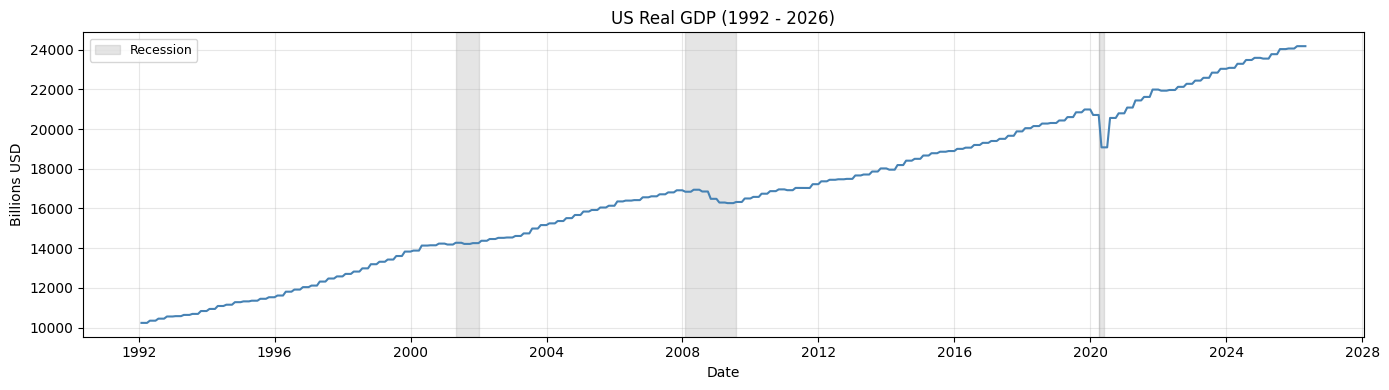

In [14]:
plot_with_recession(df_trim['GDP'], 
                    'US Real GDP (1992 - 2026)', 
                    'Billions USD', 
                    'steelblue')

The overall story of US GDP from 1992 to 2026 is one of remarkable long run growth interrupted by three distinct shocks. The economy grew from roughly 8 trillion dollars to over 23 trillion over three decades. What stands out is that in levels GDP never really looks like it crashes, the line just briefly flattens or dips slightly before resuming its upward march. This is actually misleading and it is one reason why we will transform GDP into growth rates later. The growth rate tells a far more dramatic and honest story about what happened during recessions than the raw level does.

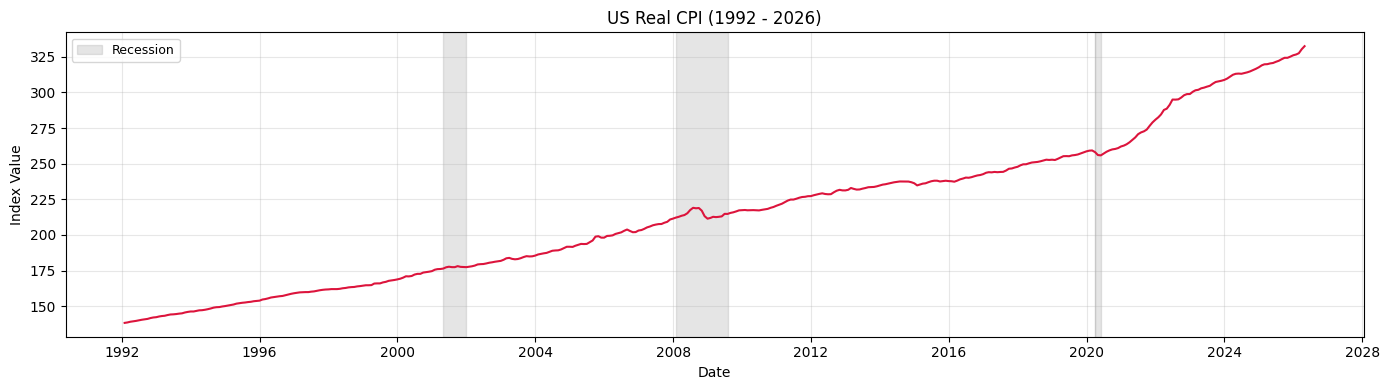

In [15]:
plot_with_recession(df_trim['CPI'], 
                    'US Real CPI (1992 - 2026)', 
                    'Index Value', 
                    'crimson')

Inflation has gone through distinct regimes over this period. It was relatively stable and low through most of the 1990s and 2000s which reflects the era of what economists called the Great Moderation. The most dramatic feature is the sharp acceleration starting around 2021, the steepest rise in consumer prices in four decades driven by pandemic supply chain disruptions and stimulus spending. What is also interesting is that CPI barely flinched during the 2001 recession and only slowed slightly in 2008. Inflation is clearly a lagging indicator, it responds slowly to economic changes rather than leading them.

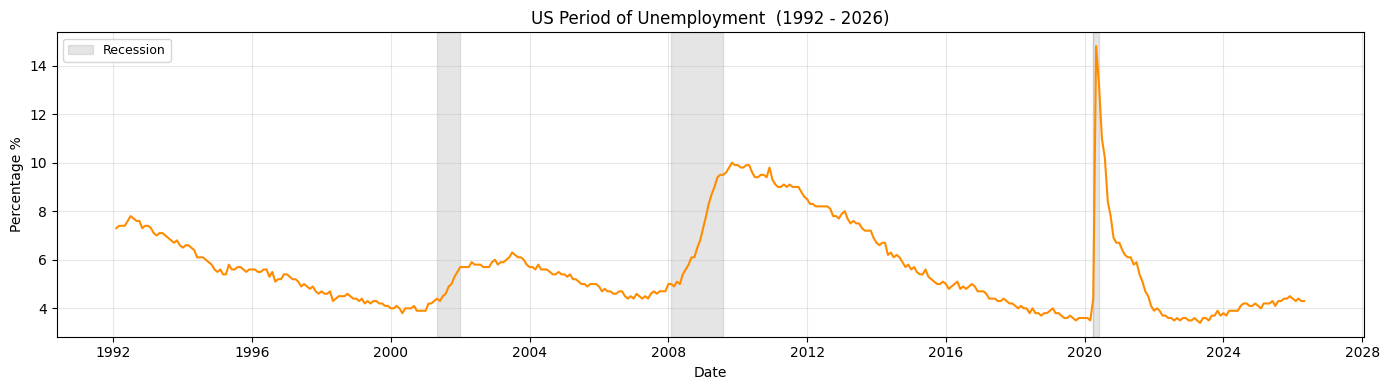

In [16]:
plot_with_recession(df_trim['Unemployment'], 
                    'US Period of Unemployment  (1992 - 2026)', 
                    'Percentage %', 
                    'darkorange')

Unemployment behaves exactly as economic theory predicts, it rises after recessions begin not before them. This makes it a lagging indicator and means it cannot serve as an early warning signal on its own. The 2008 crisis produced the most sustained unemployment spike with rates climbing above 10 percent and staying elevated for years. The 2020 COVID spike was the most sudden and dramatic unemployment event in modern US history, millions of jobs vanished in weeks, but the recovery was also unusually fast as the economy reopened. What matters for our model is not the unemployment level itself but how fast it is changing.

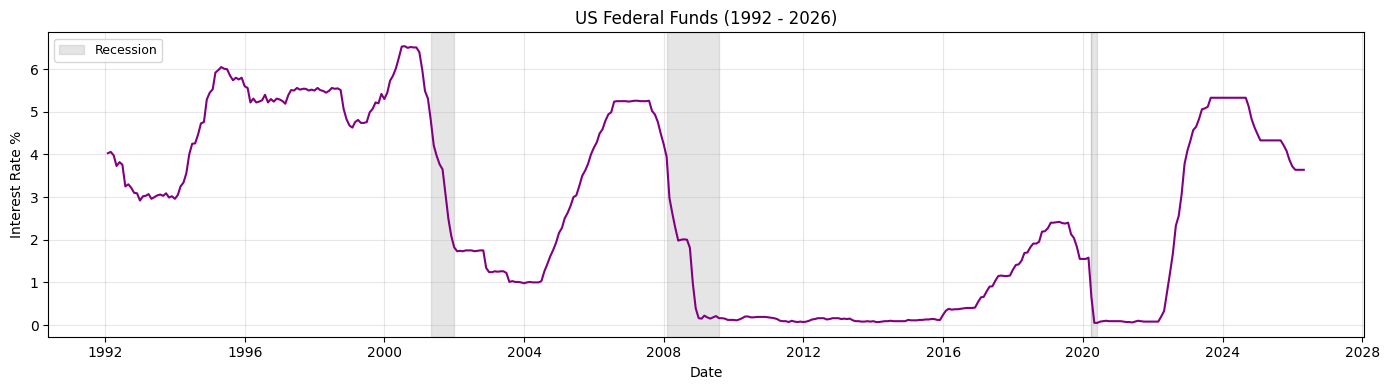

In [17]:
plot_with_recession(df_trim['FedFunds'], 
                    'US Federal Funds (1992 - 2026)', 
                    'Interest Rate %', 
                    'purple')

The Federal Reserve's interest rate decisions tell a fascinating story when plotted against recession periods. A clear pattern emerges across multiple cycles, the Fed raises rates aggressively to cool an overheating economy and then cuts them sharply when recession hits. This happened before 2001, before 2008, and again before 2020. The most recent hiking cycle from 2022 to 2023 was the most aggressive in decades as the Fed fought to bring post-pandemic inflation under control. The key insight for MacroSense is that rate changes do not affect the economy immediately, the full impact typically takes 6 to 18 months to flow through to GDP and unemployment. This delay is exactly why including lagged versions of this variable in our model makes sense.

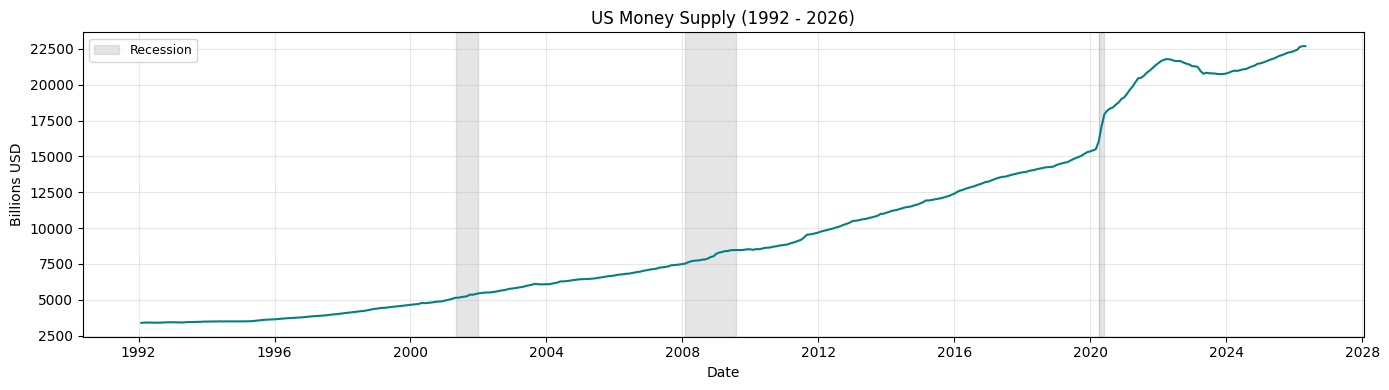

In [18]:
plot_with_recession(df_trim['M2'], 
                    'US Money Supply (1992 - 2026)', 
                    'Billions USD', 
                    'teal')

Money supply grew steadily for most of this period reflecting normal economic expansion. The most striking feature is the near vertical spike in 2020 and 2021 as the Federal Reserve pumped unprecedented amounts of money into the economy through quantitative easing and stimulus programmes. This was the largest and fastest expansion of the money supply in US history. What followed, the inflation surge of 2021 and 2022, was almost a textbook consequence. Too much money chasing too few goods. The chart is a visual reminder that monetary policy decisions have real and sometimes dramatic consequences that show up in other variables months or years later.

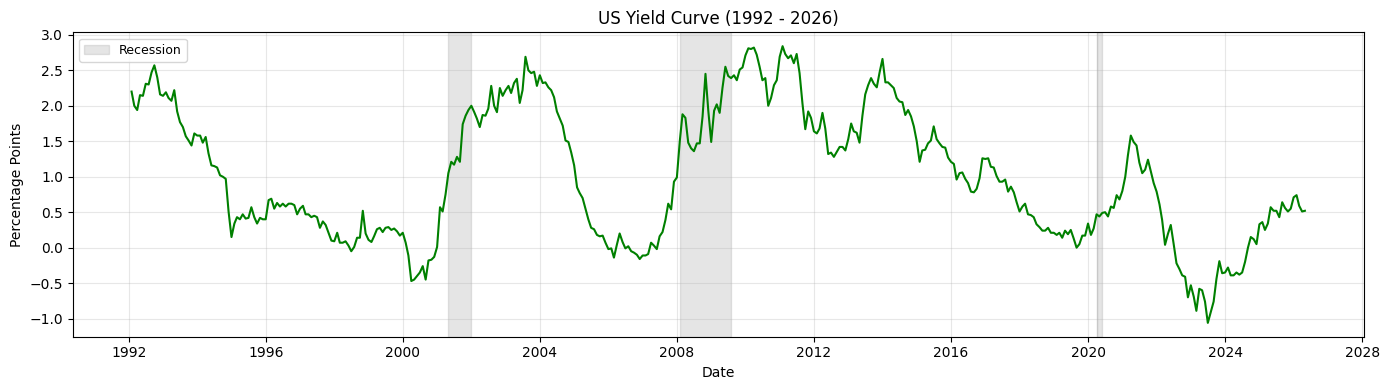

In [19]:
plot_with_recession(df_trim['YieldCurve'], 
                    'US Yield Curve (1992 - 2026)', 
                    'Percentage Points', 
                    'green')

The yield curve is probably the most interesting variable in this entire dataset. Unlike most economic indicators that react to what is already happening, this one has a track record of warning you before things go wrong.
What caught my attention immediately was how the green line dips below zero three distinct times, around 2000, again around 2006, and most recently starting around 2023. The first two inversions were not random noise. The 2000 inversion was followed by the Dot-com recession in 2001. The 2006 inversion preceded the Global Financial Crisis of 2008. Both times the yield curve was essentially flashing a warning signal that most people ignored.
The third inversion is the one that really makes you think. Starting around 2023 the yield curve went negative again and has only recently started recovering. Whether this translates into a full recession or the economy manages a so called soft landing remains to be seen as of 2026. But history suggests ignoring this signal is unwise.
This is exactly why the yield curve spread is one of our most important input variables. It does not just reflect what the economy is doing right now , it reflects what bond investors collectively believe is coming. And historically their collective judgment has been remarkably accurate.

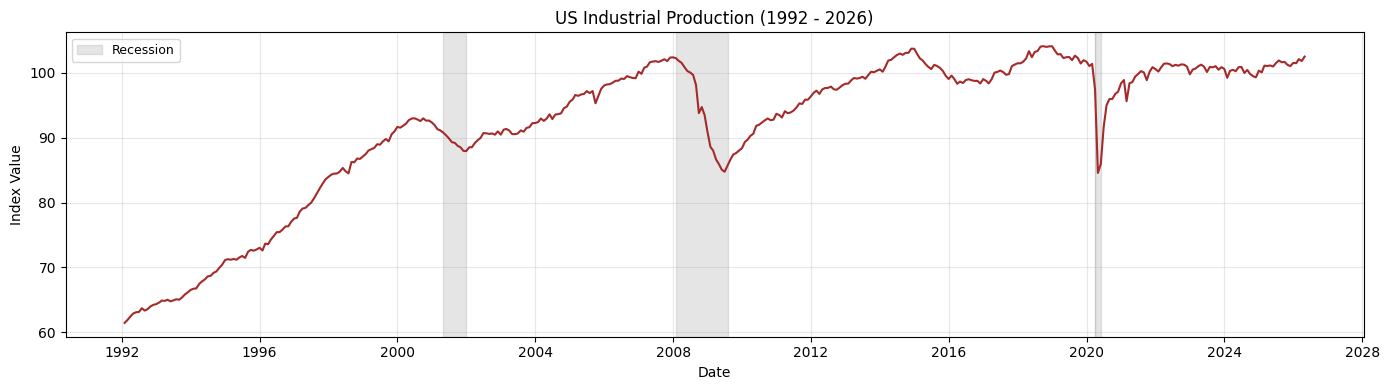

In [20]:
plot_with_recession(df_trim['IndPro'], 
                    'US Industrial Production (1992 - 2026)', 
                    'Index Value', 
                    'brown')

Industrial production is one of the more reliable recession indicators in this dataset. Factory output dropped visibly during all three recession periods though the character of each drop was different. The 2001 drop was moderate and relatively brief. The 2008 drop was deeper and more prolonged reflecting how severely the financial crisis damaged business confidence and investment. The 2020 drop was sudden and severe, lockdowns physically shut factories overnight, though the recovery was also faster than 2008 as supply chains gradually reopened. There is also a subtle softening visible in late 2019 that predates the pandemic and likely reflects the impact of the US-China trade war on American manufacturing activity.

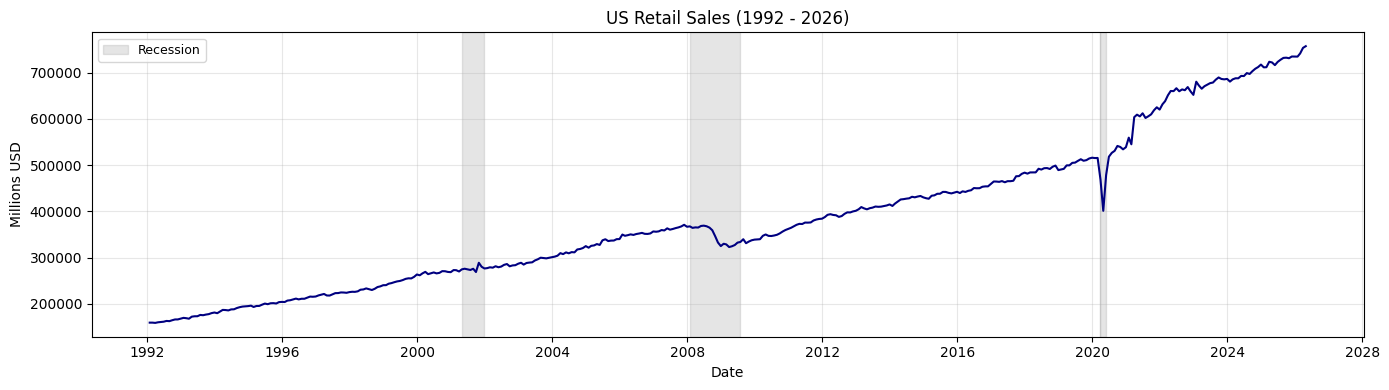

In [21]:
plot_with_recession(df_trim['RetailSales'], 
                    'US Retail Sales (1992 - 2026)', 
                    'Millions USD', 
                    'navy')

Retail sales tells perhaps the most interesting story of all the variables in this dataset because its behaviour during recessions is not uniform. The 2001 recession caused barely a ripple in retail spending, consumers kept shopping even as the stock market crashed suggesting the Dot-com bust was largely confined to financial markets and technology workers. The 2008 crisis produced a more visible and sustained decline as job losses and falling home values eroded consumer confidence over many months. The 2020 pattern is unlike anything else in this dataset, a sudden catastrophic drop as lockdowns shuttered physical retail followed by an explosive recovery driven by government stimulus and a shift toward online and goods spending. The long run upward trend in retail sales is ultimately a reflection of population growth, inflation, and rising living standards over three decades.

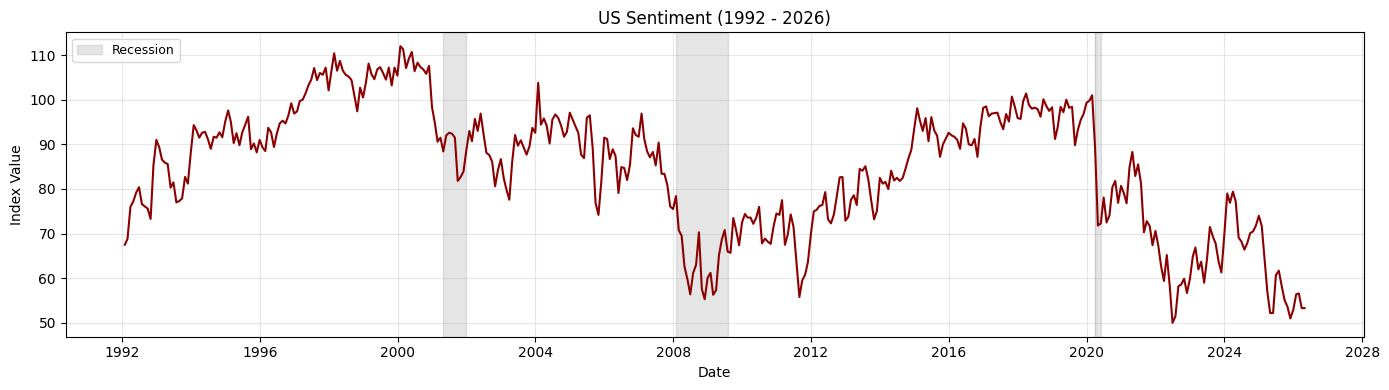

In [22]:
plot_with_recession(df_trim['Sentiment'], 
                    'US Sentiment (1992 - 2026)', 
                    'Index Value', 
                    'darkred')

Consumer sentiment stands out as one of the more reliable leading indicators in this dataset. In both 2001 and 2008 sentiment started declining before the recession officially began, consumers sensed trouble coming before economists confirmed it. This makes intuitive sense. People read news, feel job insecurity, and worry about their finances before those concerns show up in official economic statistics. The sharp sentiment collapse in 2020 was simultaneous with the recession rather than leading it, understandable given that a global pandemic arrived with almost no warning. What is notable about the current period is that sentiment has remained relatively subdued even as the economy avoided a technical recession after the 2022 to 2023 rate hiking cycle. This divergence between how people feel and how the economy is actually performing is one of the more puzzling features of the post-pandemic period.

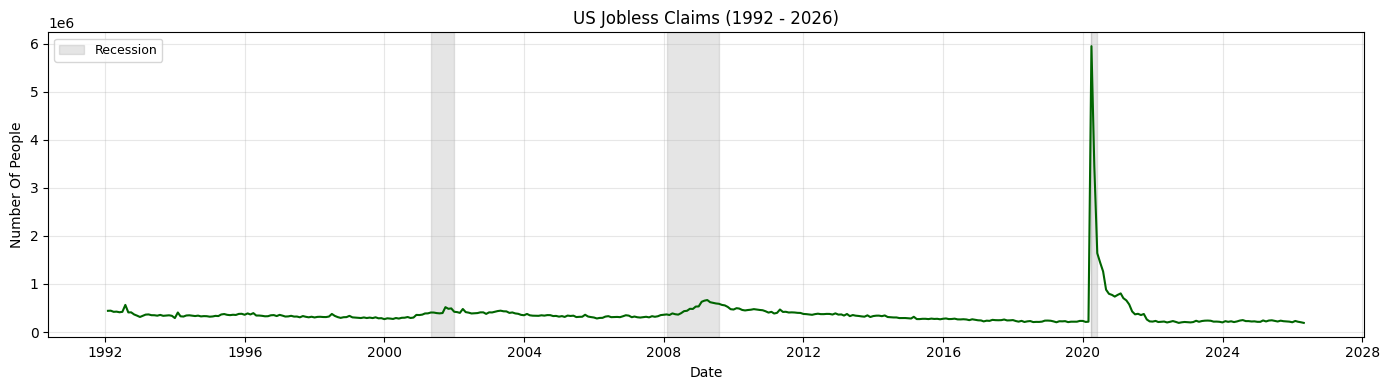

In [23]:
plot_with_recession(df_trim['JoblessClaims'], 
                    'US Jobless Claims (1992 - 2026)', 
                    'Number Of People', 
                    'darkgreen')

Weekly jobless claims is the most timely labour market indicator in our dataset, released every Thursday by the US Department of Labor. The spikes during each recession are unmistakable. The 2020 spike is in a completely different category from anything else in the chart, claims reached levels that had never been seen before as millions of workers were laid off within weeks of lockdowns beginning. What is useful about this variable for MacroSense is that it responds very quickly to economic deterioration, often within weeks of conditions changing. This timeliness makes it a valuable early signal even though it tends to confirm a recession that has just begun rather than predicting one months in advance.

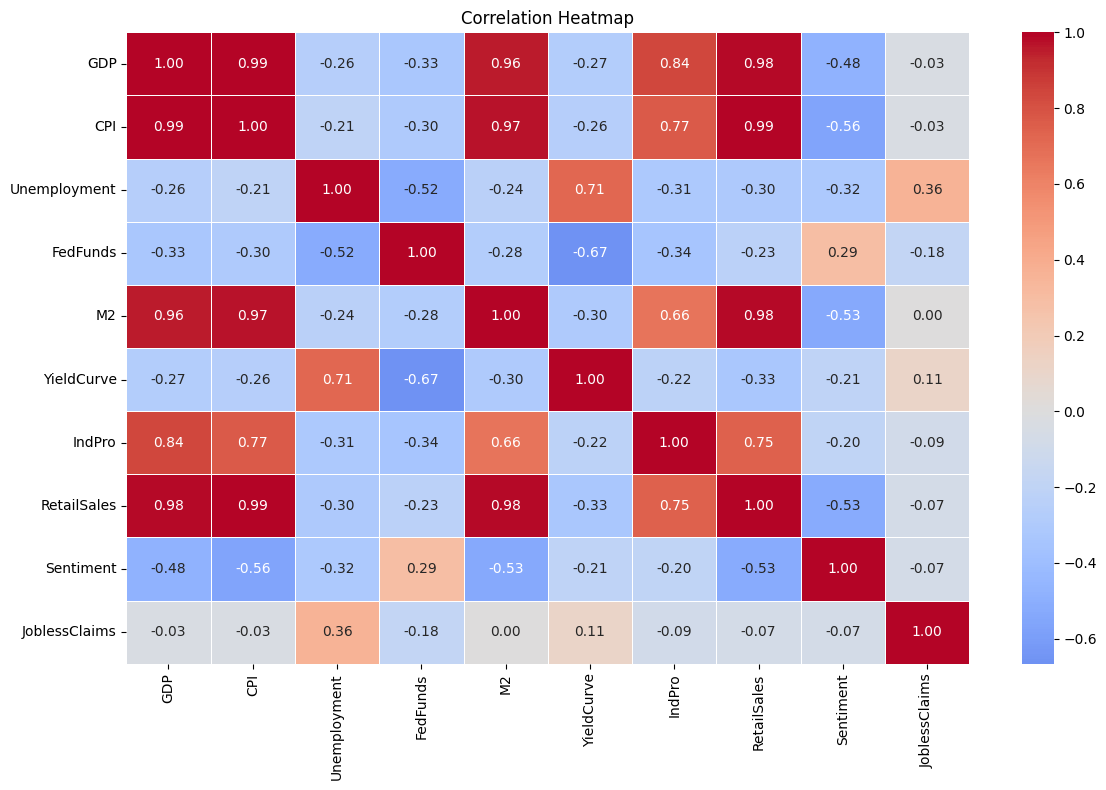

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_trim.corr(), annot=True, fmt='.2f', cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f'../charts/Correlation Heat Map.png', dpi=150, bbox_inches='tight')
plt.show()

Two variables can be highly correlated simply because they both trend in the same direction over time without one actually causing or predicting the other. This is why transforming level variables into growth rates before modelling is not optional, it is the difference between a model that learns real economic relationships and one that learns mathematical coincidences.

The correlation heatmap reveals some genuinely important patterns 
worth paying attention to before we start modelling.

The most striking finding is the near perfect correlation between 
GDP and CPI at 0.99 and between GDP and M2 at 0.96. At first 
glance this looks impressive but it is actually a warning sign 
rather than a useful insight. Both pairs share the same problem, they are level variables that trend upward over time. Their 
high correlation reflects the fact that they both get bigger over 
34 years rather than any deep causal relationship. This is 
spurious correlation in action and it is exactly why transforming 
these variables into growth rates in the next notebook is not 
optional. Feeding raw levels into a machine learning model would 
teach it mathematical coincidences rather than genuine economic 
relationships.

The negative correlations tell a more honest story. GDP and 
unemployment show a negative relationship of 0.26 confirming 
what economists call Okun's Law, when the economy grows jobs 
are created and unemployment falls. GDP and the yield curve also 
show a slight negative relationship which makes sense given that 
yield curve inversion tends to precede economic slowdowns.

One subtlety worth noting is that jobless claims and unemployment 
are only 0.36 correlated despite both measuring labour market 
stress. This is because they measure fundamentally different 
things. Jobless claims measure the flow of new unemployment 
filings each week while unemployment measures the total stock of 
people without jobs. You can have high weekly filings and still 
see stable unemployment if people are finding new jobs quickly. 
For forecasting purposes jobless claims is actually more valuable 
because it reacts faster, within weeks of economic conditions 
changing rather than months later.

The overall picture from this heatmap reinforces one central 
message. The raw data as downloaded from FRED contains real 
economic relationships but they are buried under spurious 
trending correlations that will mislead any model trained on 
them directly. Feature engineering is the solution.

Notebook 2 is done. The data has been explored thoroughly and 
the key patterns are now clear. Three recession periods are 
visible across all charts, the 2001 Dot-com bust, the 2008 
Financial Crisis, and the 2020 COVID shock. Each one left a 
distinct fingerprint across different variables and no two 
recessions behaved in exactly the same way.

The most important takeaway from this entire notebook is not 
any single chart or correlation number. It is the understanding 
that raw FRED data in its current form cannot go directly into 
a machine learning model. The level variables trend upward 
creating spurious correlations. GDP reports quarterly creating 
gaps. The signals are real but buried. 

Notebook 3 fixes all of that through feature engineering, 
transforming raw levels into meaningful growth rates, creating 
lag features that give the model a memory of the past, and 
building the target variables that define exactly what 
MacroSense is trying to predict.